**Un ejemplo simple de un problema de optimización usando ADMM**

alejandro.garces@utp.edu.co

$\min \; (x-1)^2 + |x|$    


In [1]:
using LinearAlgebra
using Plots

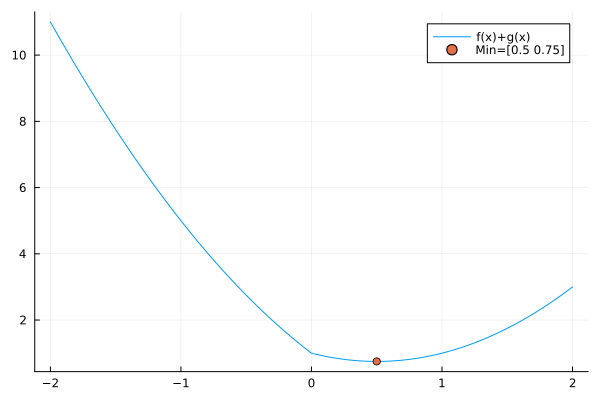

In [172]:
# El problema tiene una solución trivial que se puede encontrar mediante la grafica
f(x) = (x-1)^2
g(x) = abs(x)
xp = -2:0.01:2
yp = f.(xp).+g.(xp)
i = argmin(yp)
s =
plot(xp,yp,label="f(x)+g(x)")
scatter!([xp[i]],[yp[i]],markersize = 4,label="Min="*string(round.([xp[i] yp[i]],digits=4)))

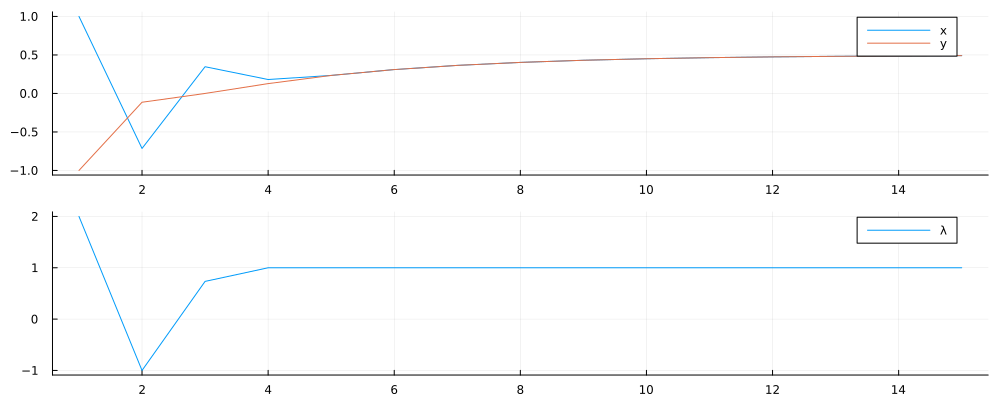

In [195]:
#Ahora usamos ADMM para encontrar el óptimo
ρ = 0.2
prox_f(u) = (u+2*ρ)/(2*ρ+1)
function prox_g(u)
    if u>ρ
        return u-ρ
    else
        if u>=-ρ
            return 0
        else
            return u+ρ
        end
    end
end

# Espacio para guardar los vectores
np = 15
x = zeros(np)
y = zeros(np)
λ = zeros(np)
# Inicializacion
x[1] = 1
y[1] = -1
λ[1] = 2
for k = 2:np
    x[k] = prox_f(y[k-1]-ρ*λ[k-1])
    y[k] = prox_g(x[k]+ρ*λ[k-1])
    λ[k] = λ[k-1] + 1/ρ*(x[k]-y[k])
end
p1=plot(x,label="x")
p1=plot!(y,label="y")
p2=plot(λ,label="λ")
plot(p1,p2,layout=(2,1),size=(1000,400))

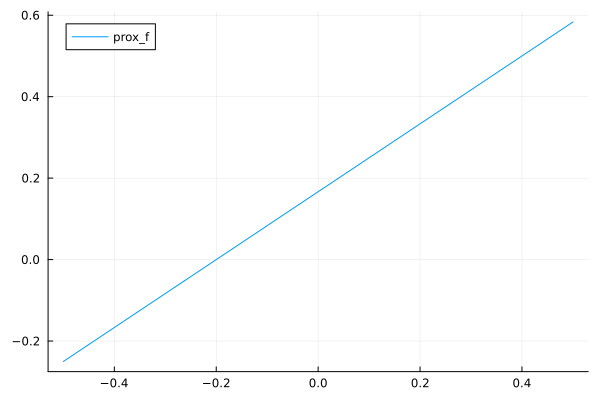

In [176]:
# Forma del operador proximal de f
nu = 100
u = -0.5:0.1:0.5
plot(u,prox_f.(u),label="prox_f")

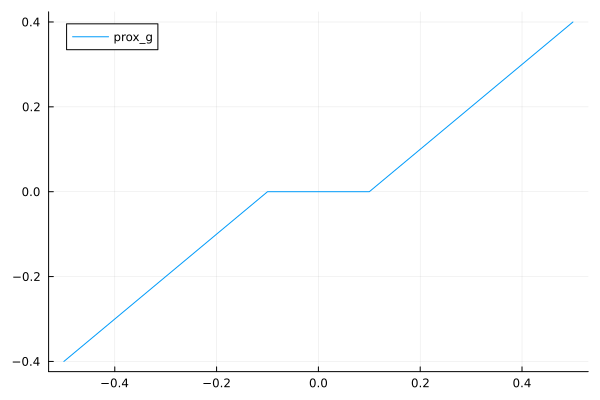

In [177]:
# Forma del operador proximal de g
nu = 100
u = -0.5:0.1:0.5
plot(u,prox_g.(u),label="prox_g")